In [346]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Export to DataBase
from sqlalchemy import create_engine, types
from dotenv import dotenv_values
from scipy.stats import ttest_ind, shapiro
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

In [347]:
# Load config
config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_pass = config['POSTGRES_PASS']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
DB_URL = f"postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
# Now building the URL with the values from the .env file
engine = create_engine(DB_URL, echo=False)


# Hypothesis 5: A higher dietary sodium-to-potassium ratio is positively associated with an increased prevalence of hypertension(elevated systolic and diastolic blood pressure)

In [348]:
try:
    engine = create_engine(DB_URL, echo=False) # echo=True prints SQL statements (useful for debugging)
    print("SQLAlchemy engine created successfully.")
except Exception as e:
    print(f"Error creating SQLAlchemy engine: {e}")
    print("Please check your database connection details and ensure the PostgreSQL driver (psycopg2-binary) is installed.")
  
    exit()

SQLAlchemy engine created successfully.


In [349]:
table_to_read = 'demographic_data' 

sql_query = f"SELECT * FROM {pg_schema}.{table_to_read}"

In [350]:
try:
    df_demo = pd.read_sql_query(sql_query, con=engine)
    print(f"\nSuccessfully read table '{table_to_read}' into a DataFrame.")
    print("\n--- First 5 rows of the DataFrame ---")
    print(df.head())
    print("\n--- DataFrame Info ---")
    df.info()
except Exception as e:
    print(f"Error reading SQL table '{table_to_read}': {e}")
    print("Possible reasons: Table does not exist, incorrect table name, incorrect schema, or connection issue.")


Successfully read table 'demographic_data' into a DataFrame.

--- First 5 rows of the DataFrame ---
Empty DataFrame
Columns: [Participant_ID, Age, Gender, Hypertensive, BMI, sodium_to_potassium_ratio, Gender_Coded]
Index: []

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Participant_ID             0 non-null      int64  
 1   Age                        0 non-null      int64  
 2   Gender                     0 non-null      object 
 3   Hypertensive               0 non-null      int64  
 4   BMI                        0 non-null      float64
 5   sodium_to_potassium_ratio  0 non-null      float64
 6   Gender_Coded               0 non-null      int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 0.0+ bytes


In [351]:
df_demo.columns

Index(['Participant_ID', 'Interview_Exam_Status', 'Age_Years', 'Gender',
       'Race_Ethnicity', 'Education_Level_Adults', 'Income_Poverty_Ratio',
       'Marital_Status', 'Country_of_Birth', 'Household_Size',
       'Pregnancy_Status', 'Interview_Weight', 'Exam_Weight'],
      dtype='object')

In [352]:
table_to_read = 'hypertension_risk_factor_ratios' 

sql_query = f"SELECT * FROM {pg_schema}.{table_to_read}"
df_ratios = pd.read_sql_query(sql_query, con=engine)

In [353]:
table_to_read = 'merged_demo_hypertensive_bmi_data' 

sql_query = f"SELECT * FROM {pg_schema}.{table_to_read}"
df_demo_bmi = pd.read_sql_query(sql_query, con=engine) 

In [354]:
df_demo_bmi

,Participant_ID,Age,Gender,Hypertensive,BMI,WHR,BMI_Category,Abdominal_Obesity
0,130378,43,male,True,27.0,1.0,overweight,True
1,130379,66,male,True,33.5,1.0,obese,True
2,130380,44,female,False,29.7,1.0,overweight,True
3,130386,34,male,False,30.2,1.0,obese,True
4,130387,68,female,True,42.6,0.8,obese,False
...,...,...,...,...,...,...,...,...
7796,142306,9,male,False,15.4,NaN,underweight,None
7797,142307,49,female,True,NaN,NaN,None,None
7798,142308,50,male,False,26.4,1.0,overweight,True
7799,142309,40,male,True,25.5,0.9,overweight,True


In [355]:
df_ratios = df_ratios.rename(columns={'seqn_no': 'Participant_ID'})
df_merged = pd.merge(df_demo_bmi,df_ratios,on='Participant_ID',how='inner')  # Or 'inner' if you only want participants with both data

In [356]:
# Merge after filtering df_demo_bmi by age range (20–80)
df_merged = (
    df_demo_bmi.loc[df_demo_bmi['Age'].between(20, 80)]
    .merge(df_ratios, on='Participant_ID', how='inner')
)

In [357]:
df_analysis = df_merged[[
    'Participant_ID',
    'Age',
    'Gender',
    'Hypertensive',
    'BMI',
    'sodium_to_potassium_ratio'
]]

In [358]:

# Export to CSV

file_path = "../data/analysis_data/hypertension_demo_nutrient_analysis.csv" 

try:
    df_analysis.to_csv(file_path, index=False, encoding='utf-8')
    print(f"DataFrame successfully saved to: {file_path}")
except Exception as e:
    print(f"Error saving DataFrame to CSV: {e}")
    

DataFrame successfully saved to: ../data/analysis_data/hypertension_demo_nutrient_analysis.csv


In [ ]:
df_analysis.info()

In [ ]:
# --- 2. Data Preparation ---
df_analysis['Hypertensive'] = df_analysis['Hypertensive'].astype(bool)
df_analysis['sodium_to_potassium_ratio'] = pd.to_numeric(df_analysis['sodium_to_potassium_ratio'], errors='coerce')

# Drop NA if any
df_analysis.dropna(subset=['sodium_to_potassium_ratio', 'Hypertensive'], inplace=True)

In [ ]:
(df_analysis['Age']<20).sum()

In [359]:
df_analysis.describe()

,Participant_ID,Age,BMI,sodium_to_potassium_ratio
count,4798.000000,4798.00000,4748.000000,4.798000e+03
mean,136315.791788,55.04481,29.981487,4.479160e+76
std,3448.805784,16.84210,7.357369,3.075971e+78
min,130378.000000,20.00000,11.100000,5.000000e-02
25%,133274.000000,41.00000,24.900000,9.300000e-01
50%,136364.500000,59.00000,28.600000,1.250000e+00
75%,139265.750000,68.00000,33.700000,1.660000e+00
max,142310.000000,80.00000,74.800000,2.130574e+80


In [360]:
df_analysis.groupby('Hypertensive')['sodium_to_potassium_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
Hypertensive,,,,,,,,
False,2094.0,1.335597e+00,6.330521e-01,0.10,0.91,1.23,1.62,9.360000e+00
True,2704.0,7.947859e+76,4.097400e+78,0.05,0.94,1.27,1.69,2.130574e+80


# ---  Normality Check (Shapiro-Wilk test) ---

In [361]:
# --- 3. Normality Check (Shapiro-Wilk test) ---
print("\n--- Normality Test (Shapiro-Wilk) ---")
for label, group in df_analysis.groupby('Hypertensive'):
    stat, p = shapiro(group['sodium_to_potassium_ratio'])
    status = 'normal' if p > 0.05 else 'not normal'
    print(f"Hypertensive = {label}: W = {stat:.3f}, p = {p:.4f} → Data is {status}.")


--- Normality Test (Shapiro-Wilk) ---
Hypertensive = False: W = 0.864, p = 0.0000 → Data is not normal.
Hypertensive = True: W = 0.005, p = 0.0000 → Data is not normal.


Shapiro-Wilk: The result shows that the Data is not Normal

# --- T-test ---

In [362]:
# --- 4. T-test ---
ratio_h = df_analysis[df_analysis['Hypertensive']]['sodium_to_potassium_ratio']
ratio_nh = df_analysis[~df_analysis['Hypertensive']]['sodium_to_potassium_ratio']

t_stat, p_val = ttest_ind(ratio_h, ratio_nh, equal_var=False, alternative='greater')

print("\n--- T-test ---")
print(f"Hypertensive mean: {ratio_h.mean():.2f}, n={len(ratio_h)}")
print(f"Non-Hypertensive mean: {ratio_nh.mean():.2f}, n={len(ratio_nh)}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")


--- T-test ---
Hypertensive mean: 79478593796027678955845685016742003543249426229021576188095593645143490560000.00, n=2704
Non-Hypertensive mean: 1.34, n=2094
T-statistic: 1.009
P-value: 0.1566


T-test: Shows if hypertensive group has significantly higher sodium-to-potassium ratios.

Regression: Adjusts for confounders like Age, Gender, and BMI. If Hypertensive is still significant here, the association is stronger.

In [363]:
(df_analysis['Hypertensive']== False).count()

np.int64(4798)

In [364]:
# --- 5. Regression Analysis ---
print("\n--- Multiple Regression Analysis ---")

# Regression model
formula = 'sodium_to_potassium_ratio ~ Hypertensive + Age + Gender + BMI'
model = smf.ols(formula=formula, data=df_analysis).fit()

print(model.summary())



--- Multiple Regression Analysis ---
                                OLS Regression Results                               
Dep. Variable:     sodium_to_potassium_ratio   R-squared:                       0.001
Model:                                   OLS   Adj. R-squared:                  0.000
Method:                        Least Squares   F-statistic:                     1.035
Date:                       Thu, 12 Jun 2025   Prob (F-statistic):              0.387
Time:                               16:09:54   Log-Likelihood:            -8.6484e+05
No. Observations:                       4748   AIC:                         1.730e+06
Df Residuals:                           4743   BIC:                         1.730e+06
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------

c:\Users\susan\miniconda3\lib\site-packages\scipy\stats\_stats_py.py:1076: RuntimeWarning: overflow encountered in square
  s = s**2
c:\Users\susan\miniconda3\lib\site-packages\numpy\_core\_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [365]:
df_analysis['sodium_to_potassium_ratio'].describe()

count    4.798000e+03
mean     4.479160e+76
std      3.075971e+78
min      5.000000e-02
25%      9.300000e-01
50%      1.250000e+00
75%      1.660000e+00
max      2.130574e+80
Name: sodium_to_potassium_ratio, dtype: float64

In [370]:
df_analysis['sodium_to_potassium_ratio_cleaned'] = df_analysis['sodium_to_potassium_ratio'].clip(upper=high_threshold)

C:\Users\susan\AppData\Local\Temp\ipykernel_26060\900404103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['sodium_to_potassium_ratio_cleaned'] = df_analysis['sodium_to_potassium_ratio'].clip(upper=high_threshold)


<Axes: xlabel='Hypertensive', ylabel='sodium_to_potassium_ratio_cleaned'>

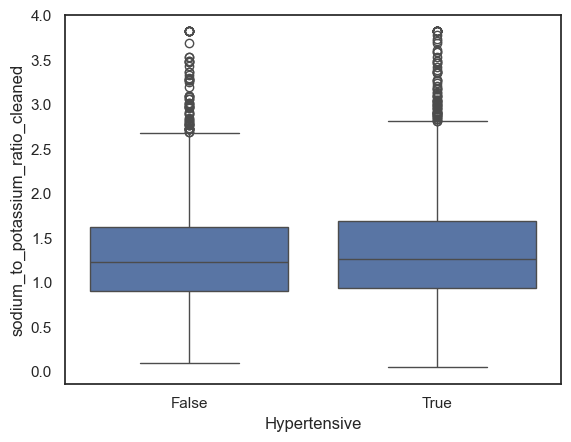

In [371]:
sns.boxplot(x='Hypertensive', y='sodium_to_potassium_ratio_cleaned', data=df_analysis)

In [372]:
# Create two groups
group_hyper = df_analysis[df_analysis['Hypertensive'] == True]['sodium_to_potassium_ratio_cleaned']
group_nonhyper = df_analysis[df_analysis['Hypertensive'] == False]['sodium_to_potassium_ratio_cleaned']

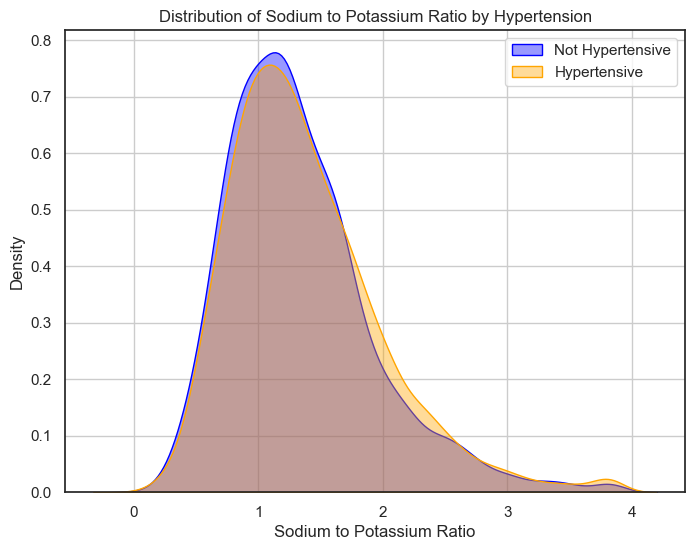

In [373]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.kdeplot(data=group_nonhyper, label='Not Hypertensive', fill=True, color='blue', alpha=0.4)
sns.kdeplot(data=group_hyper, label='Hypertensive', fill=True, color='orange', alpha=0.4)
plt.title('Distribution of Sodium to Potassium Ratio by Hypertension')
plt.xlabel('Sodium to Potassium Ratio')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = df_demo.merge(df_bp, on="Participant_ID").merge(df_bmi, on="Participant_ID")